In [1]:
%reload_ext autoreload
%autoreload 2

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from flax import nnx

from probjax.nn import GaussianFourierEmbedding
from probjax.nn.nets.flow_matching_model import LinearFlow
from functools import partial


In [3]:
# MNIST data
from datasets import load_dataset
import numpy as np

dataset = load_dataset('mnist', keep_in_memory=True)

dataset.set_format(type='numpy', columns=['image'])


In [4]:

import scipy
def img_aug(x):
    xs_batch = x["image"]
    xs_batch = scipy.ndimage.rotate(xs_batch, np.random.uniform()*10, axes=(1,2), reshape=False)

    # Normalize to [0, 1] and add small uniform noise for dequantization
    xs_batch = xs_batch.astype(np.float32) / 255.0
    xs_batch += np.random.uniform(0, 1/255, xs_batch.shape)
    # Move to [-1,1]
    xs_batch = 2*xs_batch - 1
    xs_batch = np.clip(xs_batch, -1.0, 1.0)
    return xs_batch[..., None] # Add channel dimension

In [5]:
from probjax.nn.io_util import DataLoader

loader = DataLoader(dataset["train"],batch_size=256, num_prefetch_host=64, num_prefetch_device=4, shard=False, host_transforms=img_aug, num_async_workers=4)

In [6]:
datastream = iter(loader)

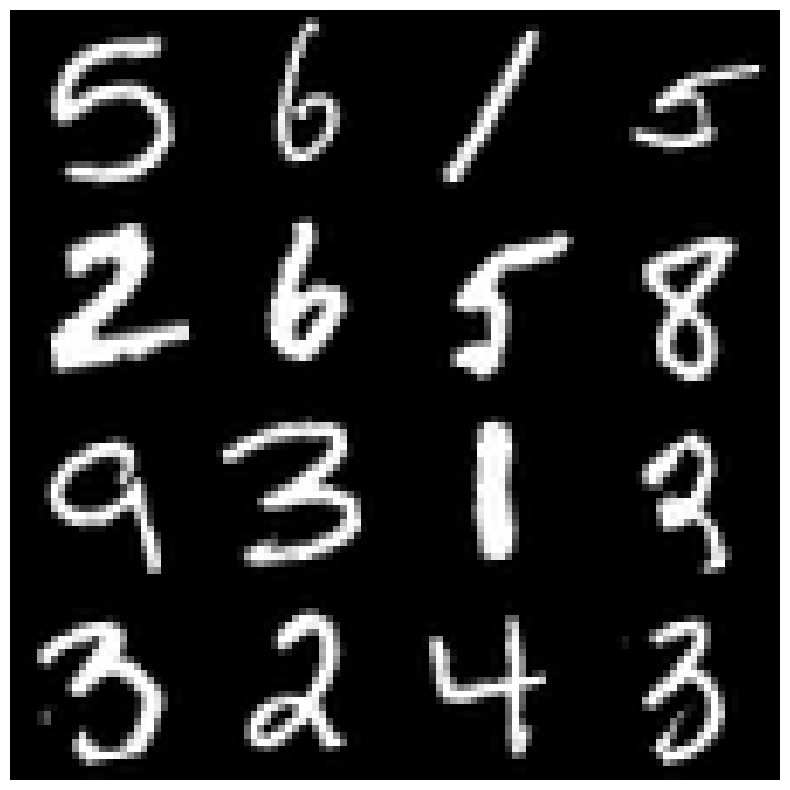

In [7]:
images = next(datastream)[:16,:,:,0]
stacked_images = np.vstack([np.hstack(images[i*4:(i+1)*4]) for i in range(4)])

plt.figure(figsize=(10, 10))
plt.imshow(stacked_images, cmap="gray")
plt.axis('off')
plt.show()


In [8]:
from probjax.nn.nets.unets import UNet, Conv, ConvTranspose, ResnetBlock, ResizeConv
from functools import partial
import time

In [9]:
xs = []
for i in range(5000):
    xs.append(next(datastream))
    time.sleep(0.001)


std1 = np.concatenate(xs, axis=0).std(0) + 0.01
mu1 = np.concatenate(xs, axis=0).mean(0)
del xs

In [10]:
shapes = [(16,16), (8,8),(4,4)]
conv_up_cls = [partial(ResizeConv, out_shape=shape) for shape in shapes]
conv_down_cls = [partial(ResizeConv, out_shape=shape)for shape in shapes]

# Alternatively try ConvTranspose
# conv_up_cls = partial(ConvTranspose, kernel_size=(3,3))
# conv_down_cls = partial(Conv, kernel_size=(3,3))

In [11]:

class Denoiser(nnx.Module):
    def __init__(self, rngs) -> None:
        self.time_embedding = GaussianFourierEmbedding(1,512, rngs=rngs, learnable=True)
        # Pass norm=nnx.GroupNorm instead of num_groups to UNet/ResnetBlock
        self.net = UNet(
            1,
            rngs=rngs,
            kernel_size=(2,2),
            strides=(1,1),
            kernel_size_resnet=(3,3),
            out_features=[64,128,256,512],
            context_features=512,
            use_attention=[False, True,True,True],
            conv_down_cls = conv_down_cls,
            conv_up_cls = conv_up_cls,
            dtype=jnp.bfloat16,
            precision="BF16_BF16_F32",
            preferred_element_type=jnp.float32,
        )

    def __call__(self, t, x, *args, **kwargs):
        time_embed = self.time_embedding(t)
        out = self.net(x, context=time_embed, *args, **kwargs)
        return out

net = Denoiser(nnx.Rngs(0))
model = LinearFlow(net, std1=std1, mu1=mu1)
params = nnx.state(model, nnx.Param)

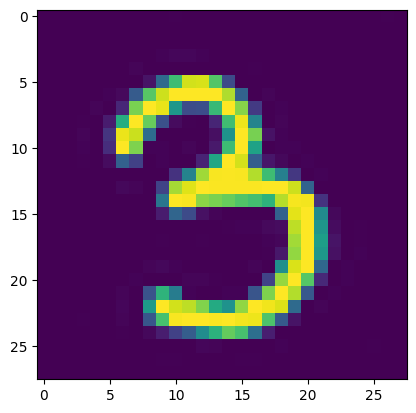

Could not load symbol cuFuncGetName. Error: /lib64/libcuda.so.1: undefined symbol: cuFuncGetName


Down: (256, 28, 28, 64)
Down: (256, 16, 16, 128)
Down: (256, 8, 8, 256)
Mid: (256, 4, 4, 512)
Up: (256, 4, 4, 256)
Up: (256, 8, 8, 128)
Up: (256, 16, 16, 64)


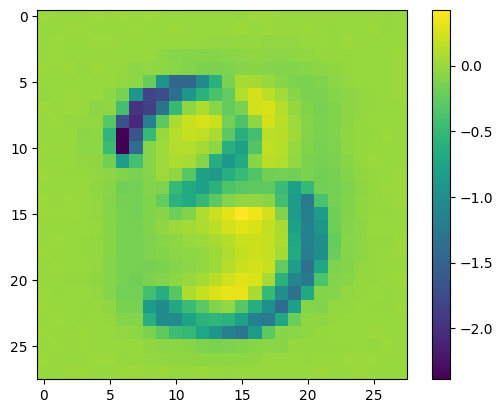

In [12]:
x = next(datastream)
plt.imshow(x[0])
plt.show()
plt.imshow(model(jnp.ones((256,1,1,1))*0.5,x,verbose=True)[0])
plt.colorbar()

In [13]:
# Count parameters
print("Number of parameters: ", sum(np.prod(v.shape) for v in jax.tree_util.tree_leaves(params)))

Number of parameters:  31786480


In [14]:
def loss_fn(params, x, rng):
    nnx.update(model, params)
    return model.loss(rng, x, axis=(-3,-2,-1), adaptive_weight_p=0.8, adaptive_weight_eps=1e-3)


In [15]:
from functools import partial
import optax

opt = optax.chain(optax.adaptive_grad_clip(5.), optax.radam(1e-4))
opt_state = opt.init(params)

@jax.jit
def update(params, opt_state, x, rng):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, rng)
    updates, opt_state = opt.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def train_step(params, opt_state, xs, rng):
    params, opt_state, losses = update(params, opt_state, xs, rng)
    return params, opt_state, jnp.mean(losses)


In [16]:
key = jax.random.key(2)

In [ ]:
params, opt_state, loss = train_step(params, opt_state, next(datastream), key)

In [ ]:
ema = optax.ema(0.9999)
ema_state = ema.init(params)

In [ ]:
# Example training iteration
for i in range(100):
    l = 0.
    for j in range(500):
        key, key_data, key_loss = jax.random.split(key, 3)
        xs = next(datastream)
        params, opt_state, loss = train_step(params, opt_state, xs, key_loss)
        l += loss
        ema_params, ema_state = ema.update(params, ema_state)
    print(l/500)

3.104204
2.7105088
2.6253242
2.5954943


KeyboardInterrupt: 

In [ ]:
nnx.update(model, ema_params)

In [ ]:
from probjax.utils.odeint import odeint



def sample(rng):
    eps = jax.random.normal(rng, (28,28,1,)) * model.std0.value + model.mu0.value
    ts = model.solve_schedule(100)

    def drift(t, x):
        t = jnp.atleast_1d(t)
        v = model(t, x)
        return v.reshape(x.shape)

    return odeint(drift, eps,ts, method="euler")[-1]


In [ ]:
keys = jax.random.split(jax.random.key(0), (16,))

In [ ]:
xs = jax.vmap(sample)(keys)

In [ ]:
xs.min(),xs.max()

(Array(-1.533, dtype=float32), Array(2.836, dtype=float32))

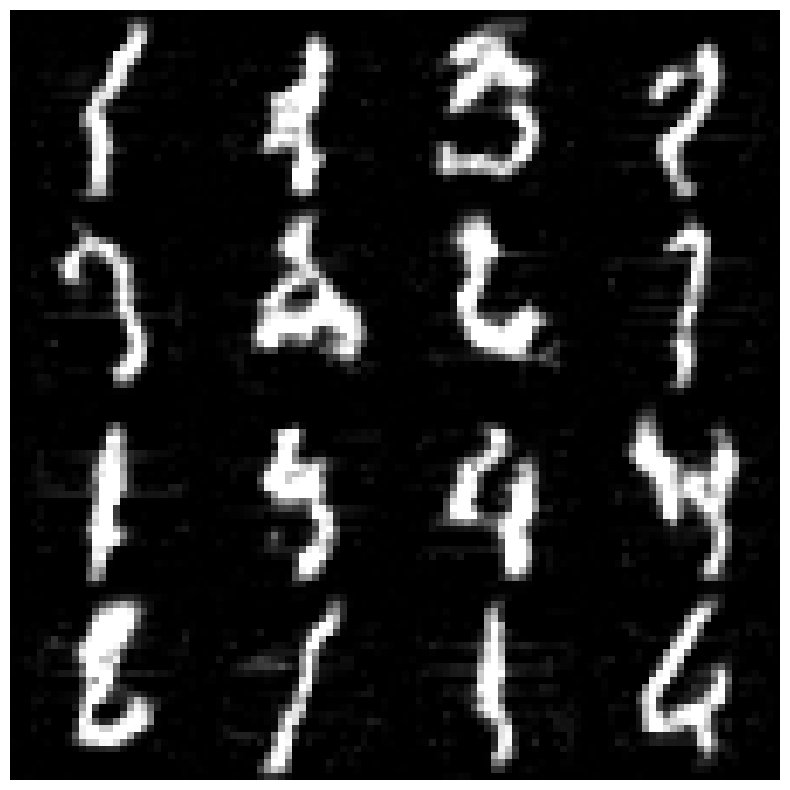

In [ ]:
import matplotlib.pyplot as plt

img = xs.reshape(4, 4, 28, 28).transpose(0, 2, 1, 3).reshape(4*28, 4*28)
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap="gray", vmin=-1, vmax=1)
plt.axis('off')
plt.show()